# Acute 4-Channel Canopy Temperature (August 2024)

This notebook focuses on the temperature mainline we agreed to use in the report:

1. Restrict to the acute experiment
2. Use 4-channel canopy temperature only
3. Restrict to August 2024
4. Compare OTC vs Control with paired window summaries
5. Save only the final outputs in the last cell


In [1]:
from datetime import datetime, timedelta
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().resolve()
if not (ROOT / "cranberry-data-group6").exists() and (ROOT.parent / "cranberry-data-group6").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.check_yield_vs_sensors import (
    ACUTE_4CH_DIR,
    acute_expected_tests,
    norm_text,
    parse_excel_time_fraction,
    parse_plot,
    parse_yyyymmdd,
    read_overview_rows,
    resolve_file_path,
)

RESULT_DIR = ROOT / "results" / "temperature"
FIG_DIR = RESULT_DIR / "figures"

WINDOW_OUT = RESULT_DIR / "acute_4ch_aug2024_window_means.csv"
PAIR_OUT = RESULT_DIR / "acute_4ch_aug2024_pair_diffs.csv"
SUMMARY_OUT = RESULT_DIR / "acute_4ch_aug2024_summary.csv"
REPORT_OUT = RESULT_DIR / "acute_4ch_aug2024_report.md"

FIG_DIFF_OUT = FIG_DIR / "acute_4ch_aug2024_otc_minus_control_hist.png"
FIG_OTC_OUT = FIG_DIR / "acute_4ch_aug2024_otc_mean_vs_target_hist.png"

print("ROOT:", ROOT)
print("ACUTE_4CH_DIR exists:", ACUTE_4CH_DIR.exists())


ROOT: /Users/liyuang/Desktop/STAT628/installment3
ACUTE_4CH_DIR exists: True


In [2]:
def canopy_channel_index(channel_var: str) -> int | None:
    text = str(channel_var or "")
    if "canopy" not in text.lower():
        return None
    match = re.match(r"\s*(\d+)", text)
    if match is None:
        return None
    idx = int(match.group(1))
    if idx < 1 or idx > 4:
        return None
    return idx


def read_4ch(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path, skiprows=1, encoding="utf-8-sig")
    ts = pd.to_datetime(raw.iloc[:, 1], format="%m/%d/%y %I:%M:%S %p", errors="coerce")
    vals = raw.iloc[:, 2:6].apply(pd.to_numeric, errors="coerce")
    out = pd.DataFrame({"timestamp": ts})
    out["ch1"] = vals.iloc[:, 0]
    out["ch2"] = vals.iloc[:, 1]
    out["ch3"] = vals.iloc[:, 2]
    out["ch4"] = vals.iloc[:, 3]
    return out.dropna(subset=["timestamp"]).sort_values("timestamp")


def acute_window(row) -> tuple[datetime, datetime] | None:
    day = parse_yyyymmdd(row.experiment_date)
    t_start = parse_excel_time_fraction(row.start_raw)
    t_end = parse_excel_time_fraction(row.end_raw)
    if day is None or t_start is None or t_end is None:
        return None
    start = datetime.combine(day, t_start)
    end = datetime.combine(day, t_end)
    if end < start:
        end = end + timedelta(days=1)
    return start, end


def heat_level_from_test(test: str) -> str:
    text = str(test or "").upper()
    if text.startswith("A0"):
        return "A0"
    if text == "":
        return ""
    return text[0]


overview = read_overview_rows()
acute_locked = pd.read_csv(ROOT / "cleaned_data" / "acute_yield_analysis_locked.csv")
acute_locked = acute_locked[acute_locked["include_in_yield_model"] == 1].copy()

# Expand yield rows to the exact acute tests expected at each heat level.
allowed = set()
for _, row in acute_locked[["cultivar", "heat_level", "is_control", "replicate"]].drop_duplicates().iterrows():
    treatment = "Control" if int(row["is_control"]) == 1 else "OTC"
    for test in acute_expected_tests(row["heat_level"]):
        allowed.add((row["cultivar"], test, treatment, int(row["replicate"])))

file_index = {norm_text(path.stem): path for path in ACUTE_4CH_DIR.glob("*.csv")}
cache = {}
rows = []

for row in overview:
    if row.stress_type != "Acute" or row.sensor != "4 channel":
        continue
    if "canopy" not in str(row.channel_var or "").lower():
        continue

    day = parse_yyyymmdd(row.experiment_date)
    if day is None or day.year != 2024 or day.month != 8:
        continue

    parsed_plot = parse_plot(row.plot)
    if parsed_plot is None:
        continue
    treatment_raw, replicate = parsed_plot
    treatment = "OTC" if str(treatment_raw).lower() == "otc" else "Control"

    key = (row.cultivar, row.test, treatment, int(replicate))
    if key not in allowed:
        continue

    path, _ = resolve_file_path(row.stress_type, row.sensor, row.file_name, file_index)
    if path is None:
        continue

    window = acute_window(row)
    if window is None:
        continue
    start, end = window

    ch = canopy_channel_index(row.channel_var)
    if ch is None:
        continue

    if path not in cache:
        cache[path] = read_4ch(path)
    sensor_df = cache[path]
    value_col = f"ch{ch}"
    sub = sensor_df[(sensor_df["timestamp"] >= start) & (sensor_df["timestamp"] <= end)][["timestamp", value_col]].rename(columns={value_col: "temp_c"})
    sub = sub.dropna(subset=["temp_c"])
    if len(sub) == 0:
        continue

    rows.append(
        {
            "cultivar": row.cultivar,
            "test": row.test,
            "heat_level": heat_level_from_test(row.test),
            "date": day.isoformat(),
            "treatment": treatment,
            "replicate": int(replicate),
            "file_stem": path.stem,
            "channel_var": row.channel_var,
            "window_start": start.isoformat(sep=" "),
            "window_end": end.isoformat(sep=" "),
            "n_points": int(len(sub)),
            "mean_temp_c": float(sub["temp_c"].mean()),
            "max_temp_c": float(sub["temp_c"].max()),
            "pct_points_ge_40": float((sub["temp_c"] >= 40.0).mean()),
        }
    )

acute_window_means = pd.DataFrame(rows).sort_values(["date", "test", "cultivar", "treatment", "replicate"]).reset_index(drop=True)

print("Window rows:", len(acute_window_means))
print("Rows by heat level and treatment:")
print(acute_window_means.groupby(["heat_level", "treatment"]).size())
acute_window_means.head(12)


Window rows: 46
Rows by heat level and treatment:
heat_level  treatment
A           Control       6
            OTC           6
B           Control      10
            OTC          12
C           Control       6
            OTC           6
dtype: int64


,cultivar,test,heat_level,date,treatment,replicate,file_stem,channel_var,window_start,window_end,n_points,mean_temp_c,max_temp_c,pct_points_ge_40
0,MQ,B1,B,2024-08-07,Control,1,Set4_Acute20240807,1_Canopy,2024-08-07 10:02:00,2024-08-07 12:02:00,121,19.292231,21.40,0.000000
1,MQ,B1,B,2024-08-07,Control,3,Set6_Acute20240807a,1_Canopy,2024-08-07 10:02:00,2024-08-07 12:02:00,121,19.549917,21.79,0.000000
2,MQ,B1,B,2024-08-07,OTC,1,Set1_Acute20240807,1_Canopy,2024-08-07 10:02:00,2024-08-07 12:02:00,120,34.466917,41.62,0.050000
3,MQ,B1,B,2024-08-07,OTC,2,Set2_Acute20240807a,1_Canopy,2024-08-07 10:02:00,2024-08-07 12:02:00,121,38.628182,46.37,0.355372
4,MQ,B1,B,2024-08-07,OTC,3,Set3_Acute20240807,1_Canopy,2024-08-07 10:02:00,2024-08-07 12:02:00,121,42.151074,50.20,0.801653
5,St,B1,B,2024-08-07,Control,1,Set4_Acute20240807,1_Canopy,2024-08-07 13:37:00,2024-08-07 15:40:00,124,23.622742,27.67,0.000000
6,St,B1,B,2024-08-07,Control,3,Set6_Acute20240807a,1_Canopy,2024-08-07 13:37:00,2024-08-07 15:40:00,124,25.949435,30.43,0.000000
7,St,B1,B,2024-08-07,OTC,1,Set1_Acute20240807,1_Canopy,2024-08-07 13:37:00,2024-08-07 15:40:00,123,31.152927,45.52,0.219512
8,St,B1,B,2024-08-07,OTC,2,Set2_Acute20240807a,1_Canopy,2024-08-07 13:37:00,2024-08-07 15:40:00,124,46.039758,52.60,0.911290
9,St,B1,B,2024-08-07,OTC,3,Set3_Acute20240807,1_Canopy,2024-08-07 13:37:00,2024-08-07 15:40:00,124,40.235000,48.36,0.588710


In [3]:
mean_wide = (
    acute_window_means
    .pivot_table(
        index=["cultivar", "heat_level", "test", "date", "replicate"],
        columns="treatment",
        values="mean_temp_c",
        aggfunc="mean",
    )
    .rename(columns={"Control": "control_mean_temp_c", "OTC": "otc_mean_temp_c"})
)

max_wide = (
    acute_window_means
    .pivot_table(
        index=["cultivar", "heat_level", "test", "date", "replicate"],
        columns="treatment",
        values="max_temp_c",
        aggfunc="mean",
    )
    .rename(columns={"Control": "control_max_temp_c", "OTC": "otc_max_temp_c"})
)

pct40_wide = (
    acute_window_means
    .pivot_table(
        index=["cultivar", "heat_level", "test", "date", "replicate"],
        columns="treatment",
        values="pct_points_ge_40",
        aggfunc="mean",
    )
    .rename(columns={"Control": "control_pct_points_ge_40", "OTC": "otc_pct_points_ge_40"})
)

acute_pairs = mean_wide.join(max_wide).join(pct40_wide).reset_index()
acute_pairs = acute_pairs.dropna(subset=["control_mean_temp_c", "otc_mean_temp_c"]).copy()
acute_pairs["temp_diff_otc_minus_control"] = acute_pairs["otc_mean_temp_c"] - acute_pairs["control_mean_temp_c"]
acute_pairs["otc_gap_to_40_c"] = acute_pairs["otc_mean_temp_c"] - 40.0

print("Paired rows:", len(acute_pairs))
print("Pairs by heat level:")
print(acute_pairs.groupby("heat_level").size())
acute_pairs.head(12)


Paired rows: 22
Pairs by heat level:
heat_level
A     6
B    10
C     6
dtype: int64


treatment,cultivar,heat_level,test,date,replicate,control_mean_temp_c,otc_mean_temp_c,control_max_temp_c,otc_max_temp_c,control_pct_points_ge_40,otc_pct_points_ge_40,temp_diff_otc_minus_control,otc_gap_to_40_c
0,MQ,A,A3,2024-08-28,1,23.414050,40.139504,27.22,45.72,0.0,0.677686,16.725455,0.139504
1,MQ,A,A3,2024-08-28,2,23.595620,37.670165,25.36,41.51,0.0,0.173554,14.074545,-2.329835
2,MQ,A,A3,2024-08-28,3,23.427438,40.017521,25.24,44.22,0.0,0.694215,16.590083,0.017521
3,MQ,B,B1,2024-08-07,1,19.292231,34.466917,21.40,41.62,0.0,0.050000,15.174685,-5.533083
5,MQ,B,B1,2024-08-07,3,19.549917,42.151074,21.79,50.20,0.0,0.801653,22.601157,2.151074
6,MQ,B,B2,2024-08-21,1,19.304463,37.574545,22.14,45.75,0.0,0.314050,18.270083,-2.425455
7,MQ,B,B2,2024-08-21,2,18.891405,34.754417,20.85,40.32,0.0,0.008333,15.863012,-5.245583
8,MQ,B,B2,2024-08-21,3,18.603967,38.694711,20.84,44.59,0.0,0.404959,20.090744,-1.305289
9,MQ,C,C1,2024-08-14,1,24.549453,38.769606,31.52,42.77,0.0,0.362205,14.220153,-1.230394
10,MQ,C,C1,2024-08-14,2,23.970000,39.669685,29.35,42.80,0.0,0.566929,15.699685,-0.330315


In [4]:
def acute_summary_table(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    grouped = [(("overall",), df)] if not group_cols else list(df.groupby(group_cols))
    for key, sub in grouped:
        if not isinstance(key, tuple):
            key = (key,)
        vals = sub["temp_diff_otc_minus_control"].dropna().to_numpy()
        if len(vals) < 2:
            t_stat, p_value, se = np.nan, np.nan, np.nan
        else:
            t_stat, p_value = stats.ttest_1samp(vals, 0.0)
            se = vals.std(ddof=1) / np.sqrt(len(vals))
        row = {
            "n_pairs": int(len(vals)),
            "mean_control_temp_c": float(sub["control_mean_temp_c"].mean()),
            "mean_otc_temp_c": float(sub["otc_mean_temp_c"].mean()),
            "mean_diff_otc_minus_control": float(np.nanmean(vals)) if len(vals) else np.nan,
            "mean_otc_gap_to_40_c": float(sub["otc_gap_to_40_c"].mean()),
            "mean_otc_pct_points_ge_40": float(sub["otc_pct_points_ge_40"].mean()),
            "sd_diff": float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else np.nan,
            "se_diff": se,
            "t_stat": t_stat,
            "p_value": p_value,
        }
        for col, value in zip(group_cols, key):
            row[col] = value
        rows.append(row)
    cols = group_cols + [
        "n_pairs",
        "mean_control_temp_c",
        "mean_otc_temp_c",
        "mean_diff_otc_minus_control",
        "mean_otc_gap_to_40_c",
        "mean_otc_pct_points_ge_40",
        "sd_diff",
        "se_diff",
        "t_stat",
        "p_value",
    ]
    return pd.DataFrame(rows)[cols]


summary_by_level = acute_summary_table(acute_pairs, ["heat_level"])
summary_overall = acute_summary_table(acute_pairs, [])
summary = pd.concat([summary_overall, summary_by_level], ignore_index=True, sort=False)

print("Summary rows:", len(summary))
summary


Summary rows: 4


,n_pairs,mean_control_temp_c,mean_otc_temp_c,mean_diff_otc_minus_control,mean_otc_gap_to_40_c,mean_otc_pct_points_ge_40,sd_diff,se_diff,t_stat,p_value,heat_level
0,22,22.271245,38.330781,16.059536,-1.669219,0.382923,3.402142,0.725339,22.140727,4.863612e-16,NaN
1,6,22.568333,38.038581,15.470248,-1.961419,0.337466,1.428728,0.583276,26.523048,1.424278e-06,A
2,10,21.556284,37.805010,16.248726,-2.194990,0.393095,4.373122,1.382903,11.749724,9.212310e-07,B
3,6,23.165758,39.499267,16.333509,-0.500733,0.411428,3.401472,1.388645,11.762192,7.812752e-05,C


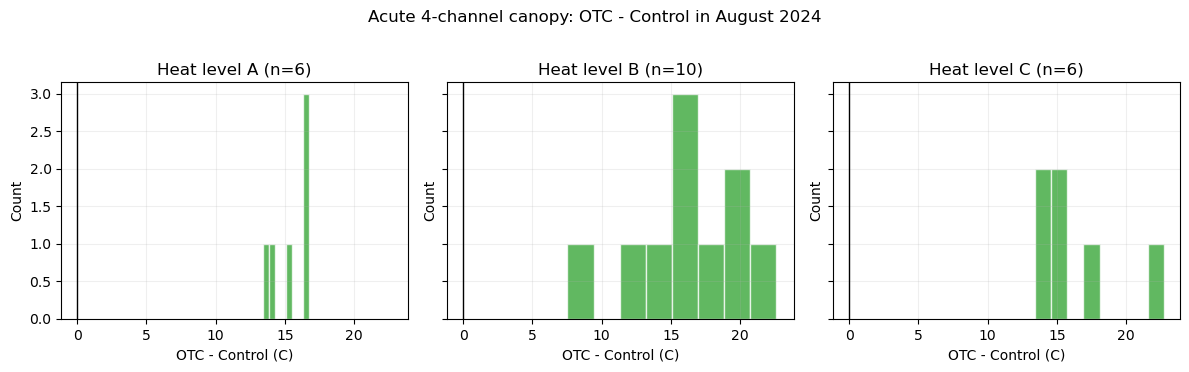

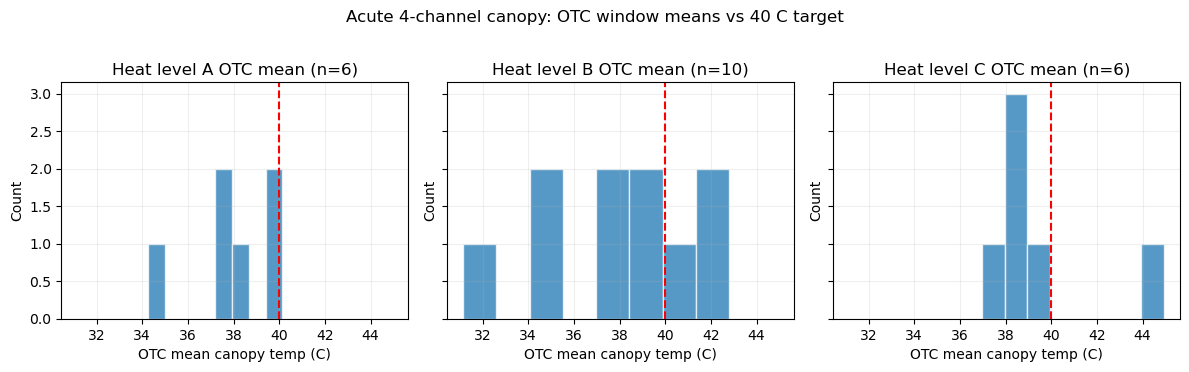

Saved: /Users/liyuang/Desktop/STAT628/installment3/results/temperature/figures/acute_4ch_aug2024_otc_minus_control_hist.png
Saved: /Users/liyuang/Desktop/STAT628/installment3/results/temperature/figures/acute_4ch_aug2024_otc_mean_vs_target_hist.png


In [5]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

levels = sorted(summary_by_level["heat_level"].dropna().tolist())
ncols = 3
nrows = int(np.ceil(len(levels) / ncols)) if levels else 1

# Histogram 1: OTC - Control paired differences by heat level.
fig1, axes = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)
for i, level in enumerate(levels):
    ax = axes[i]
    vals = acute_pairs.loc[acute_pairs["heat_level"] == level, "temp_diff_otc_minus_control"].to_numpy()
    ax.hist(vals, bins=8, alpha=0.75, color="#2ca02c", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Heat level {level} (n={len(vals)})")
    ax.set_xlabel("OTC - Control (C)")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
for j in range(len(levels), len(axes)):
    axes[j].axis("off")
fig1.suptitle("Acute 4-channel canopy: OTC - Control in August 2024", y=1.02)
fig1.tight_layout()
fig1.savefig(FIG_DIFF_OUT, dpi=180)
plt.show()

# Histogram 2: OTC window mean temperatures vs 40 C target.
fig2, axes = plt.subplots(nrows, ncols, figsize=(12, 3.6 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)
for i, level in enumerate(levels):
    ax = axes[i]
    vals = acute_pairs.loc[acute_pairs["heat_level"] == level, "otc_mean_temp_c"].to_numpy()
    ax.hist(vals, bins=8, alpha=0.75, color="#1f77b4", edgecolor="white")
    ax.axvline(40, color="red", linewidth=1.5, linestyle="--")
    ax.set_title(f"Heat level {level} OTC mean (n={len(vals)})")
    ax.set_xlabel("OTC mean canopy temp (C)")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
for j in range(len(levels), len(axes)):
    axes[j].axis("off")
fig2.suptitle("Acute 4-channel canopy: OTC window means vs 40 C target", y=1.02)
fig2.tight_layout()
fig2.savefig(FIG_OTC_OUT, dpi=180)
plt.show()

print("Saved:", FIG_DIFF_OUT)
print("Saved:", FIG_OTC_OUT)


In [6]:
report_lines = [
    "# Acute 4-Channel Canopy Temperature Report (August 2024)",
    "",
    f"- Generated at: {datetime.now().isoformat(timespec='seconds')}",
    "- Scope: acute experiment only, 4-channel canopy only, August 2024 only.",
    "- Primary comparison: paired OTC vs Control window mean canopy temperature.",
    "- HOBO data were excluded from the mainline because of missing mappings/files/window coverage.",
    "",
    "## Data coverage",
    f"- Window rows: {len(acute_window_means)}",
    f"- Paired rows: {len(acute_pairs)}",
    "",
    "## Overall result",
]

overall = summary.iloc[0]
report_lines.append(
    f"- Overall OTC - Control mean difference = {overall['mean_diff_otc_minus_control']:.3f} C (p={overall['p_value']}, n={int(overall['n_pairs'])})."
)
report_lines.append(
    f"- Overall OTC mean canopy temperature = {overall['mean_otc_temp_c']:.3f} C; mean gap to 40 C = {overall['mean_otc_gap_to_40_c']:.3f} C."
)
report_lines.append(
    f"- Mean fraction of in-window readings >= 40 C in OTC plots = {overall['mean_otc_pct_points_ge_40']:.3f}."
)

report_lines.extend([
    "",
    "## By heat level",
])

for _, row in summary_by_level.iterrows():
    report_lines.append(
        f"- {row['heat_level']}: diff={row['mean_diff_otc_minus_control']:.3f} C, OTC mean={row['mean_otc_temp_c']:.3f} C, OTC gap to 40 C={row['mean_otc_gap_to_40_c']:.3f} C, p={row['p_value']} (n={int(row['n_pairs'])})."
    )

report_lines.extend([
    "",
    "## Outputs",
    f"- {WINDOW_OUT}",
    f"- {PAIR_OUT}",
    f"- {SUMMARY_OUT}",
    f"- {FIG_DIFF_OUT}",
    f"- {FIG_OTC_OUT}",
    f"- {REPORT_OUT}",
    "",
])

print("\n".join(report_lines[:25]))


# Acute 4-Channel Canopy Temperature Report (August 2024)

- Generated at: 2026-03-22T16:42:25
- Scope: acute experiment only, 4-channel canopy only, August 2024 only.
- Primary comparison: paired OTC vs Control window mean canopy temperature.
- HOBO data were excluded from the mainline because of missing mappings/files/window coverage.

## Data coverage
- Window rows: 46
- Paired rows: 22

## Overall result
- Overall OTC - Control mean difference = 16.060 C (p=4.863611869984568e-16, n=22).
- Overall OTC mean canopy temperature = 38.331 C; mean gap to 40 C = -1.669 C.
- Mean fraction of in-window readings >= 40 C in OTC plots = 0.383.

## By heat level
- A: diff=15.470 C, OTC mean=38.039 C, OTC gap to 40 C=-1.961 C, p=1.4242781036788954e-06 (n=6).
- B: diff=16.249 C, OTC mean=37.805 C, OTC gap to 40 C=-2.195 C, p=9.212309511233884e-07 (n=10).
- C: diff=16.334 C, OTC mean=39.499 C, OTC gap to 40 C=-0.501 C, p=7.812752297283711e-05 (n=6).

## Outputs
- /Users/liyuang/Desktop/STAT628/inst

In [7]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

acute_window_means.to_csv(WINDOW_OUT, index=False)
acute_pairs.to_csv(PAIR_OUT, index=False)
summary.to_csv(SUMMARY_OUT, index=False)
REPORT_OUT.write_text("\n".join(report_lines), encoding="utf-8")

print("Wrote files:")
for path in [WINDOW_OUT, PAIR_OUT, SUMMARY_OUT, FIG_DIFF_OUT, FIG_OTC_OUT, REPORT_OUT]:
    print("-", path)


Wrote files:
- /Users/liyuang/Desktop/STAT628/installment3/results/temperature/acute_4ch_aug2024_window_means.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/temperature/acute_4ch_aug2024_pair_diffs.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/temperature/acute_4ch_aug2024_summary.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/temperature/figures/acute_4ch_aug2024_otc_minus_control_hist.png
- /Users/liyuang/Desktop/STAT628/installment3/results/temperature/figures/acute_4ch_aug2024_otc_mean_vs_target_hist.png
- /Users/liyuang/Desktop/STAT628/installment3/results/temperature/acute_4ch_aug2024_report.md
